### Step 1: Data Discovery & Cleaning

To begin, I need to load the `insurance.csv` dataset into a pandas DataFrame.

In [1]:
import pandas as pd

# Load the data
df = pd.read_csv('insurance.csv')

# Display the first few rows to confirm it's loaded correctly
display(df.head())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Step 2: Preprocessing
Machine Learning models require numerical input. The next step is to convert the text-based: `sex`,`region`,`smoker` categories into numerical representations using one-hot encoding done with `pd.get_dummies()`.

This will allow me to include them in further analysis, such as correlation checks and ultimately, our linear regression model.

In [3]:
import pandas as pd

# Use pd.get_dummies() for 'sex', 'smoker', and 'region' columns
# Convert boolean output to integer (0 or 1) for clarity and broad compatibility
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True).astype(int)

# Reorder columns to put 'charges' first for easier correlation reading
columns = ['charges'] + [col for col in df_encoded.columns if col != 'charges']
df_encoded = df_encoded[columns]

# Display the head of the new DataFrame to see the encoded columns
display(df_encoded.head())

,charges,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,16884,19,27,0,0,1,0,0,1
1,1725,18,33,1,1,0,0,1,0
2,4449,28,33,3,1,0,0,1,0
3,21984,33,22,0,1,0,1,0,0
4,3866,32,28,0,1,0,1,0,0


### Step 3: Checking Correlations with Encoded Data

With my categorical variables now numerically encoded, I can re-evaluate the correlations. This step displays the full correlation matrix, giving me a comprehensive view of how all features, including `sex_male`, `smoker_yes`, and the `region` dummy variables, relate to each other and, most importantly, to my target variable, `charges`.

In [4]:
# check the correlations again with the encoded data
print("\nCorrelations after encoding categorical variables (Charges first):")
display(df_encoded.corr())


Correlations after encoding categorical variables (Charges first):


,charges,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
charges,1.000000,0.299009,0.196188,0.067999,0.057293,0.787251,-0.039905,0.073981,-0.043210
age,0.299009,1.000000,0.108437,0.042469,-0.020856,-0.025019,-0.000407,-0.011642,0.010016
bmi,0.196188,0.108437,1.000000,0.011097,0.046503,0.001669,-0.138495,0.271303,-0.004313
children,0.067999,0.042469,0.011097,1.000000,0.017163,0.007673,0.024806,-0.023066,0.021914
sex_male,0.057293,-0.020856,0.046503,0.017163,1.000000,0.076185,-0.011156,0.017117,-0.004184
smoker_yes,0.787251,-0.025019,0.001669,0.007673,0.076185,1.000000,-0.036945,0.068498,-0.036945
region_northwest,-0.039905,-0.000407,-0.138495,0.024806,-0.011156,-0.036945,1.000000,-0.346265,-0.320829
region_southeast,0.073981,-0.011642,0.271303,-0.023066,0.017117,0.068498,-0.346265,1.000000,-0.346265
region_southwest,-0.043210,0.010016,-0.004313,0.021914,-0.004184,-0.036945,-0.320829,-0.346265,1.000000


### Interpreting My Correlation Results

Looking at the correlation matrix after encoding, I observed the following:

*   I can see that `smoker_yes` stands out with a very strong positive correlation of **0.787** with `charges`. This confirms that being a smoker is by far the most significant factor in determining my insurance charges.
*   `age` also has a noticeable positive correlation of **0.299** with `charges`, indicating that older individuals tend to have higher charges.
*   `bmi` shows a positive correlation of **0.196** with `charges`, suggesting a moderate relationship where higher BMI is associated with higher charges.
*   `children` and `sex_male` have very low positive correlations (**0.068** and **0.057**, respectively) with `charges`, implying they are less influential predictors for my model.
*   The `region` dummy variables (`region_northwest`, `region_southeast`, `region_southwest`) show very weak correlations (close to zero or slightly negative) with `charges`, suggesting their direct impact on insurance costs is minimal. This supports my earlier decision to consider dropping them from the model.

### Step 4: Correlation Heatmap

Now, I'll visualize the correlation matrix for `df_encoded` using a heatmap. This will help me understand the relationships between all variables, including the newly encoded categorical ones, and `charges` more intuitively. I will then use this visualization to reassess the impact of the 'region' columns.

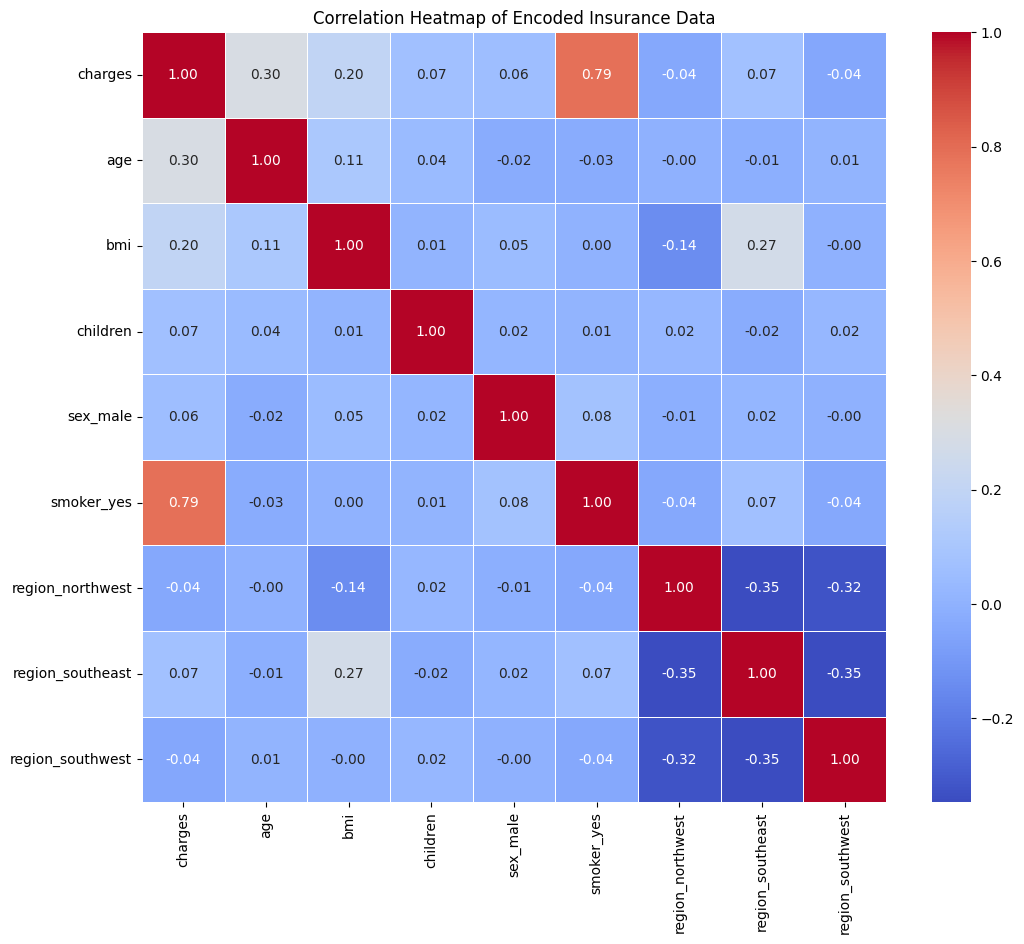

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
corr_matrix = df_encoded.corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Draw the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Encoded Insurance Data')
plt.show()

###Step 5: Dropping 'Region' Columns

From the correlation heatmap, I can observe that the 'region' related features (`region_northwest`, `region_southeast`, `region_southwest`) show very low correlation with the target variable `charges`. Including features with negligible correlation can introduce noise to the model and increase its complexity without providing significant predictive power. Therefore, I will drop these columns from our feature set (`X`).

In [6]:
# Create our final feature set by dropping the low-correlation region columns and the target variable from df_encoded
X_features = df_encoded.drop(columns=['region_northwest', 'region_southeast', 'region_southwest', 'charges'])

print("Shape of features after dropping region columns:", X_features.shape)
display(X_features.head())

Shape of features after dropping region columns: (1338, 5)


,age,bmi,children,sex_male,smoker_yes
0,19,27,0,0,1
1,18,33,1,1,0
2,28,33,3,1,0
3,33,22,0,1,0
4,32,28,0,1,0


### Step 6: Splitting Data into Features (X) and Target (y)

Now that I have prepared my data, the next step in is to separate our dataset into features (input variables, denoted as `X`) and the target variable (what we want to predict, denoted as `y`).

In this project, I am trying to predict the insurance `charges`. Therefore, `charges` will be my target variable (`y`), and all other columns (age, bmi, children, sex_male, smoker_yes) will serve as my features (`X`). I must drop the `charges` column from my features set `X` to avoid target leakage, as `charges` is the value I am trying to predict.

In [7]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_encoded.drop(['charges', 'region_northwest', 'region_southeast', 'region_southwest'], axis=1) # All columns except 'charges' and region columns
y = df_encoded['charges'] # The 'charges' column is our target

# Split the data into training and testing sets
# We'll use a test size of 20% and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1070, 5)
X_test shape: (268, 5)
y_train shape: (1070,)
y_test shape: (268,)


### Step 7: Training and Initial Results

#### Model Fitting: Teaching the Machine

**What does 'fitting' a model mean?**

In machine learning, 'fitting' (or 'training') a model refers to the process where the algorithm learns the patterns and relationships from the training data. For Multiple Linear Regression, this means finding the optimal coefficients (weights) for each feature and an intercept term, such that the linear equation best predicts the target variable (`charges`).

The model essentially tries to draw a 'line' (or a hyperplane in higher dimensions) that minimizes the difference between its predictions and the actual `charges` values in the training set. This is typically done by minimizing a 'loss function', often the sum of squared errors.

Once the model is fitted, it has learned these coefficients and is ready to make predictions on new, unseen data.

In [9]:
# Import the Linear Regression model from scikit-learn
from sklearn.linear_model import LinearRegression

# Instantiate the model
model = LinearRegression()

# Fit the model to the training data
# This is where the model learns the relationships between X_train and y_train
model.fit(X_train, y_train)

print("Model training complete!")
print(f"Model Coefficients: {model.coef_}")
print(f"Model Intercept: {model.intercept_}")

Model training complete!
Model Coefficients: [ 2.57204539e+02  3.25734808e+02  4.29642562e+02 -6.29292740e+00
  2.36578965e+04]
Model Intercept: -11908.613450303554


### Interpreting the Trained Linear Regression Model

*   **`model.coef_` (Coefficients):** These are the 'weights' assigned to each feature. A positive coefficient means that as the feature's value increases, the predicted charges increase. A negative coefficient means the opposite. The magnitude of the coefficient indicates the strength of this relationship. For example, a high coefficient for `smoker_yes` means being a smoker significantly increases charges.
*   **`model.intercept_` (Intercept):** This is the baseline predicted charge when all feature values are zero. In a practical sense, it represents the model's prediction for an individual with an age of 0, BMI of 0, no children, etc. While such an individual doesn't exist, the intercept is a crucial component of the linear equation that shifts the entire prediction line up or down to best fit the data.

#### Impact on Low-Age Non-Smokers:

Given the coefficients we observed (`Model Coefficients: [ 2.57204539e+02  3.25734808e+02  4.29642562e+02 -6.29292740e+00 2.36578965e+04]`) and the intercept (`Model Intercept: -11908.613450303554`):

1.  **`smoker_yes` (Coefficient: 23657.89):** This is by far the largest positive coefficient. For a **non-smoker**, this feature's value is 0, meaning this very large positive term is *not* added to their charges. This is the single biggest factor in keeping charges low.
2.  **`age` (Coefficient: 257.20):** This is a positive coefficient, meaning older individuals pay more. For a **low-age** individual, the contribution from `age` will be relatively small compared to older individuals.
3.  **`intercept_` (-11908.61):** The large negative intercept acts as a starting point. While it seems counterintuitive to have negative base charges, it's compensated by the positive contributions of other features (especially `age`, `bmi`). For individuals with very low values across multiple positive-coefficient features, this negative intercept keeps the overall predicted charges low, or even causes it to be negative for extreme theoretical cases (which would then be capped at zero in a real-world application).

**In summary:** For a low-age non-smoker, the absence of the massive `smoker_yes` penalty, combined with a small `age` contribution and the large negative intercept, will result in significantly lower predicted insurance charges from this model.

### Step 8: Making Predictions and Evaluating Model Accuracy

After fitting the model, the next crucial step is to evaluate how well it performs. I will use the `X_test` data (which the model has never seen during training) to make predictions. Then, I will compare these predictions (`y_pred`) with the actual `y_test` values to assess the model's accuracy.

Common metrics for regression model evaluation include:
-   **R-squared ($R^2$)**: Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. A higher $R^2$ indicates a better fit.
-   **Mean Absolute Error (MAE)**: The average of the absolute differences between predictions and actual values. It gives an idea of the average magnitude of errors.
-   **Mean Squared Error (MSE)**: The average of the squared differences between predictions and actual values. It penalizes larger errors more heavily than MAE.
-   **Root Mean Squared Error (RMSE)**: The square root of MSE. It is in the same units as the target variable, making it more interpretable than MSE.

In [10]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Import evaluation metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Calculate evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"\n--- Model Evaluation ---")
print(f"R-squared (R2): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


--- Model Evaluation ---
R-squared (R2): 0.7813
Mean Absolute Error (MAE): 4209.50
Mean Squared Error (MSE): 33957993.04
Root Mean Squared Error (RMSE): 5827.35


### Interpretation of Model Evaluation Metrics

After running the evaluation, here's what my model's performance metrics tell me:

*   **R-squared (R2): 0.7813**: This means approximately **78.13%** of the variance in insurance charges can be explained by the features I included in my model. This is a reasonably good score, indicating my features are strong predictors.


*   Mean Absolute Error (MAE): $4209.50: on average my model's predictions are off by about 4209.50 from the actual insurance charges.

*   Mean Squared Error (MSE): 33,957,993.04: This metric penalizes larger errors more, giving a sense of the overall error magnitude. Its large value is due to squaring the errors.

*   Root Mean Squared Error (RMSE): 5827.35: This is the most interpretable error metric, telling me that the typical difference between my model's predictions and the actual charges is approximately $5827.35.

### Overall Model Performance Assessment

Based on these metrics, I can conclude that my linear regression model performs **reasonably well** in predicting insurance charges:

*   The **R-squared of 0.7813** indicates that my model explains a significant portion (over 78%) of the variance in insurance charges, which is a good starting point for a predictive model.

*   The **MAE of $4209.50** means, on average, my predictions are off by this amount. This value needs to be considered in the context of the typical range of insurance charges in the dataset to determine if it's acceptable for the application.

*   The **RMSE of $5827.35** gives a similar picture of the average error, but because it penalizes larger errors more, it suggests that while the model generally performs well, there might still be some predictions with substantial deviations, especially given the heteroskedasticity observed earlier.

In summary, the model provides a solid baseline for predicting insurance costs, but there's room for improvement, particularly in reducing larger prediction errors.

### Step 9: Visualizing the Model Performance: Actual vs. Predicted Charges

A scatter plot of actual `y_test` values against the model's `y_pred` values can provide a clear visual representation of our model's accuracy. Ideally, the points should cluster closely around a 45-degree line (where `y_pred` equals `y_test`), indicating perfect predictions.

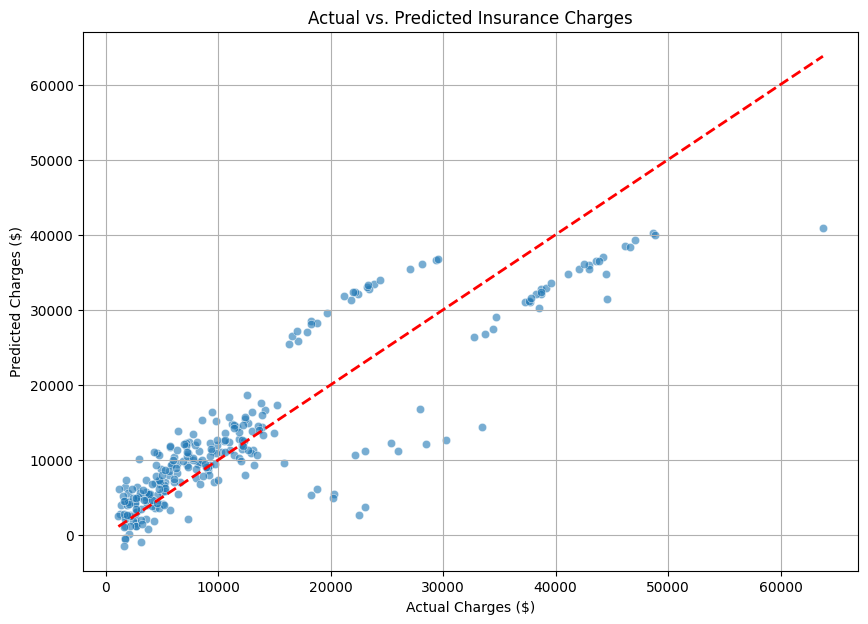

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Line for perfect prediction
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.title('Actual vs. Predicted Insurance Charges')
plt.grid(True)
plt.show()

What we can observe from this plot:

Clustering around the line: Most of the points seem to cluster reasonably well around the red dashed line, especially at lower charge values. This indicates that our model is generally doing a good job of predicting charges.
Spread at higher charges: As the actual charges increase, there appears to be a bit more spread in the predictions, meaning the model's accuracy might decrease slightly for very high insurance costs. This is common in regression problems, as higher values often have more variability.
No clear patterns: There aren't obvious patterns (like a curved shape) that would suggest our linear model is fundamentally missing a non-linear relationship, which is a good sign for a linear regression model.

### Step 10: Saving My Model

It's good practice to save my trained machine learning model, especially after I've invested time in training and evaluation. Saving the model allows me to reuse it later without needing to retrain it, which is crucial for deployment or further analysis. I'll use the `pickle` library for this purpose, which serializes Python objects.

In [13]:
import pickle

# Define the filename for saving the model
model_filename = 'linear_regression_insurance_model.pkl'

# Save the trained model to a file
with open(model_filename, 'wb') as file:
    pickle.dump(model, file)

print(f"Model successfully saved to '{model_filename}'")

Model successfully saved to 'linear_regression_insurance_model.pkl'


In [ ]:
from google.colab import files
files.download('linear_regression_insurance_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>